In [43]:
%%file weathertools.py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline

import scipy.constants as csts
from scipy.integrate import solve_ivp
from Libraries import thermodynamics as thermo
from Libraries import HT_external_convection as extconv
from Libraries import HT_natural_convection as natconv
from Libraries import HT_thermal_resistance as res
from scipy import signal
oneminute = 60.
onehour = 3600.0
oneday = 24*onehour
oneweek = 7*oneday
class WeatherData(object):
    """
    How to
    """
    def __init__(self,weather):
        interp_method = 'cubic' 
        weather['Solar Radiation'] = weather['Solar Radiation'].fillna(0.0)
        weather['Cloud Cover'] = weather['Cloud Cover'].fillna(0.0)
        weather['Precipitation'] = weather['Precipitation'].fillna(0.0)
        # weather['Dew Point'] = weather['Dew Point'].fillna(0.0)
        # weather['Precipitation'] = weather['Precipitation'].fillna(0.0)
        weather['Wind Speed'] = weather['Wind Speed'].interpolate(interp_method)
        weather['Temperature'] = weather['Temperature'].interpolate(interp_method)
        weather['Solar Radiation'] = weather['Solar Radiation'].interpolate(interp_method)
        weather['Cloud Cover'] = weather['Cloud Cover'].interpolate(interp_method)
        weather['Dew Point'] = weather['Dew Point'].interpolate(interp_method)
        weather['Precipitation'] = weather['Precipitation'].interpolate(interp_method)
        weather['Relative Humidity'] = weather['Relative Humidity'].interpolate(interp_method)
        
        weather['Temperature'] = weather['Temperature'].interpolate(interp_method)
        filtdata = {}
        sos = signal.butter(1, 1/(2*onehour), 'lp', fs=1/(15*oneminute), output='sos')
        for item in ['Solar Radiation', 
                     'Cloud Cover', 
                     'Precipitation', 
                     'Wind Speed', 
                     'Temperature',
                     'Relative Humidity',
                     'Dew Point']:
            sig = weather[item][:].to_numpy()
            sos = signal.butter(1, 1/(2*onehour), 'lp', fs=1/(15*oneminute), output='sos')
            filtdata[item] = signal.sosfilt(sos, sig)

        self.spreadsheet = weather
        t_data = np.arange(0,weather.shape[0]*15*60,15*60)
        self.t = t_data
        U_atm = np.clip(np.abs(filtdata['Wind Speed'][:]/3.6),0.,None) #converted from km/h to m/s
        T_atm = filtdata['Temperature'][:]
        q_sun = np.clip(filtdata['Solar Radiation'][:],0.0,None)
        cc = np.clip(filtdata['Cloud Cover'][:],0.,1.) # converted from % to fraction
        rh = np.clip(filtdata['Relative Humidity'][:],0.,1.) # left as %
        p_r = filtdata['Precipitation'][:]*1e-3/(15*60) #converted to mm to m/s 
        T_dp = filtdata['Dew Point'][:]
        
        interp_method = 'linear'

        # self.U_atmospheric = CubicSpline(t_data,U_atm,kind=interp_method)
        
        # self.T_atmospheric = CubicSpline(t_data,T_atm,kind=interp_method)
        
        # self.sun_irradiation = CubicSpline(t_data,q_sun,kind=interp_method)
        
        # self.cloud_cover = CubicSpline(t_data,cc,kind=interp_method)
        
        # self.dew_point = CubicSpline(t_data,T_dp,kind=interp_method)
        
        # self.relative_humidity = CubicSpline(t_data,rh,kind=interp_method)
        
        # self.rain_rate = CubicSpline(t_data,p_r,kind=interp_method)
        
        self.U_atmospheric = CubicSpline(t_data,U_atm)
        
        self.T_atmospheric = CubicSpline(t_data,T_atm)
        
        self.sun_irradiation = CubicSpline(t_data,q_sun)
        
        self.cloud_cover = CubicSpline(t_data,cc)
        
        self.dew_point = CubicSpline(t_data,T_dp)
        
        self.relative_humidity = CubicSpline(t_data,rh)
        
        self.rain_rate = CubicSpline(t_data,p_r)
    def qpp_outsideconvection(self,t,Ts,Lplate):
        Uinf = self.U_atmospheric(t)
        Tinf = self.T_atmospheric(t)
        T_f = 0.5*(Tinf + Ts)/2
        air_f = thermo.Fluid('air',T_f,'C')
        Re = np.abs(Uinf)*Lplate/air_f.nu
        Gr = natconv.Gr(beta=air_f.beta,DT=np.abs(Ts-Tinf),D=Lplate,nu=air_f.nu)
        Ra = natconv.Ra(beta=air_f.beta,DT=np.abs(Ts-Tinf),D=Lplate,nu=air_f.nu,alpha=air_f.alpha)
        if (Uinf < 0.15):
            ForcedConvection = False
            NaturalConvection = True
        else:
            Ri = Gr / Re**2
            if Ri < 0.1:
                ForcedConvection = True
                NaturalConvection = False
            elif Ri > 10:
                ForcedConvection = False
                NaturalConvection = True
            else:
                ForcedConvection = True
                NaturalConvection = True
        if ForcedConvection:
            if (Re <= 5e5):
                airflow = extconv.FlatPlate('laminar','isothermal',U_infty=Uinf,nu=air_f.nu,alpha=air_f.alpha, L=Lplate,xi=0,Re_xc= 5e5)
                airflow.average(Lplate)
                hconv_f = airflow.Nu_ave*air_f.k/Lplate
            elif Re > 5e5:
                airflow = extconv.FlatPlate('mixed','isothermal',U_infty=Uinf,nu=air_f.nu,alpha=air_f.alpha, L=Lplate,xi=0,Re_xc= 5e5)
                airflow.average(Lplate)
                hconv_f = airflow.Nu_ave*air_f.k/Lplate
        else:
            hconv_f = 0
        #Natural convection flux
        if NaturalConvection and Ra > 1e4:
            if Ts >= Tinf:
                airflow = natconv.FlatPlate(Ra,air_f.Pr,'upper','hot')
            else:
                airflow = natconv.FlatPlate(Ra,air_f.Pr,'upper','cold')
            hconv_n = airflow.Nu*air_f.k/Lplate
        else:
            hconv_n = 0
        #Total convection flux (here not a function of Ri)
        h = hconv_n + hconv_f
        qpp = h*(Ts - Tinf)
        
        return qpp
    
    def T_sky_hr(self,t,Ts):
        # Ts must be in Celsius
        Tdp = self.dew_point(t)
        cc = self.cloud_cover(t)
        Tinf = self.T_atmospheric(t)
        eps_sky = 1.
        eps_clear = 0.711 + 0.56*(Tdp/100.) + 0.73*(Tdp/100.)**2
        Ca = 1. + 0.02224*cc + 0.0035*cc**2 + 0.00028*cc**3
        Tsky  = (Ca*eps_clear)**0.25*thermo.C2K(Tinf)
        hr = eps_sky*csts.sigma*(Tsky+thermo.C2K(Ts))* \
            (Tsky**2+thermo.C2K(Ts)**2)
        return Tsky,hr
    def qpp_skyradiation(self,t,Ts):
        # Ts must be in Celsius
        Tdp = self.dew_point(t)
        cc = self.cloud_cover(t)
        Tinf = self.T_atmospheric(t)
        Tsky,hr = self.T_sky_hr(t,Ts)
        qsky = hr*(thermo.C2K(Ts) - Tsky)
        return qsky  
    def T_wet_bulb(self,T,RH):
        return T * np.arctan(0.1515977*(RH + 8.313659)**0.5) + np.arctan(T + RH) \
                - np.arctan(RH - 1.676331) + 0.00391838*RH**1.5*np.arctan(0.023101*RH) \
                - 4.686035
    def qpp_rain(self,t,Ts):
        pr = self.rain_rate(t)
        Tinf = self.T_atmospheric(t)
        RH = self.relative_humidity(t)
        Twb = self.T_wet_bulb(Tinf,RH)
    #     print("rain",pr,Twb,Tinf,RH,Ts)
        rho = 1000.0
        Cp = 4.19e3
        return rho*Cp*pr*(Ts - Twb)
        

Overwriting weathertools.py


In [1]:
import pandas as pd
loc = 'Lake Placid, NY'
weather = pd.read_excel("Climate/April-October-2020.xlsx",
                        sheet_name=loc,header=0,
                        converters= {'Date time': pd.to_datetime},)
weather = weather.set_index('Date time')
weather['Name'].head(2)

Date time
2020-04-01 00:00:00    Lake Placid, NY, United States
2020-04-01 00:15:00    Lake Placid, NY, United States
Name: Name, dtype: object

In [2]:
import weathertools as wtools

weatherfct = wtools.WeatherData(weather)

In [3]:
weatherfct.qpp_outsideconvection(0,20,70.)

108.89333307297804

In [4]:
1000/24

41.666666666666664

In [8]:
import numpy as np
sun = weather['Solar Radiation'][:]
t = np.arange(0,weather.shape[0]*15*60,15*60)

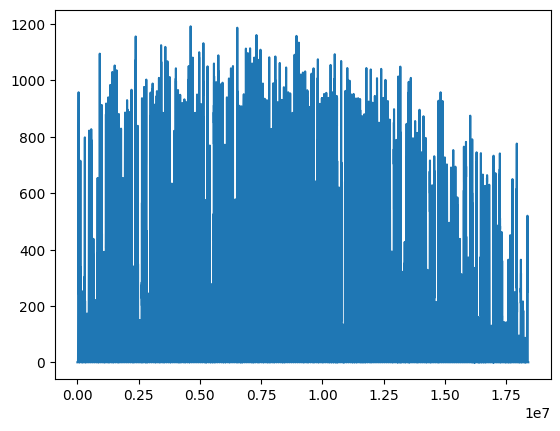

In [9]:
import matplotlib.pyplot as plt
plt.plot(t,sun)

(120.0, 125.0)

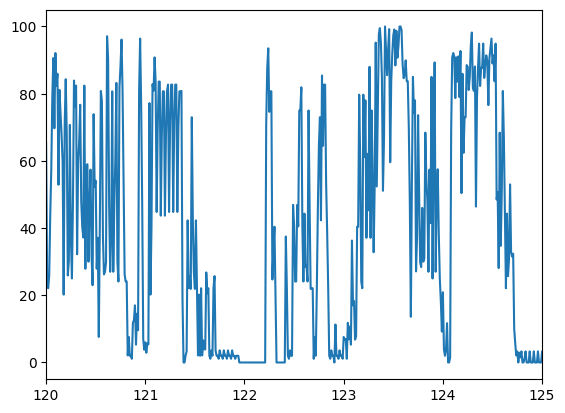

In [14]:
plt.plot(t/oneday,weather['Cloud Cover'][:])
plt.xlim(120,125)

(10368000.0, 10454400.0)

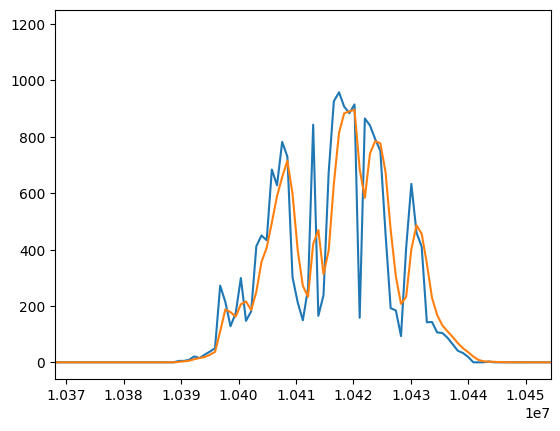

In [7]:
oneminute = 60
onehour = 60*oneminute
oneday = 24*onehour
from scipy import signal
sos = signal.butter(1, 1/(2*onehour), 'lp', fs=1/(15*oneminute), output='sos')
filtered = signal.sosfilt(sos, sun)
plt.plot(t,sun)
plt.plot(t,np.clip(filtered,0.,10000.))
plt.xlim(120*oneday,121*oneday)

In [28]:
wind = weather['Wind Speed'][:]

(9590400.0, 9676800.0)

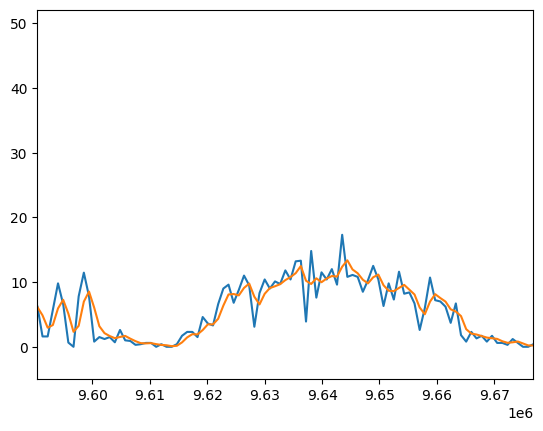

In [29]:
sos = signal.butter(1, 1/(2*onehour), 'lp', fs=1/(15*oneminute), output='sos')
filtered = signal.sosfilt(sos, wind)
plt.plot(t,wind)
plt.plot(t,np.clip(filtered,0.,10000.))
plt.xlim(111*oneday,112*oneday)

(9763200.0, 9849600.0)

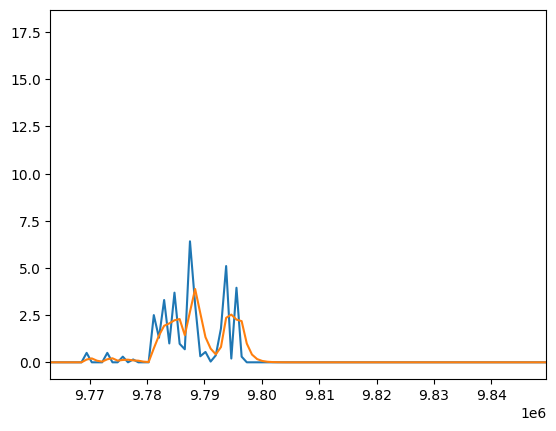

In [34]:
precip = weather['Precipitation'][:]
sos = signal.butter(1, 1/(2*onehour), 'lp', fs=1/(15*oneminute), output='sos')
filtered = signal.sosfilt(sos, precip)
plt.plot(t,precip)
plt.plot(t,np.clip(filtered,0.,10000.))
plt.xlim(113*oneday,114*oneday)